In [1]:
#Import Required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
import sklearn
print(sklearn.__version__)

1.6.1


In [3]:
#loading the dataset
df=pd.read_csv('cars24_20221210.csv')
df

,name,make,model,city,year,fueltype,kilometerdriven,ownernumber,transmission,bodytype,storename,isc24assured,registrationcity,registrationstate,benefits,discountprice,price,url,createdDate
0,Hyundai Elite i20,Hyundai,Elite I20,Kochi,2017,Petrol,35939,2,Manual,Hatchback,Kochi-Pns,False,Kozhikode,Kerala,13898,47399,607000,https://www.cars24.com/buy-used-hyundai-elite-...,2022-03-24
1,Maruti Alto 800,Maruti,Alto 800,Mumbai,2016,Petrol + Cng,6180,1,Manual,Hatchback,Hi-West Mumbai,False,Mumbai,Maharashtra,12542,2099,326000,https://www.cars24.com/buy-used-maruti-alto-80...,2022-11-09
2,Maruti Dzire,Maruti,Dzire,Lucknow,2019,Petrol + Cng,46808,1,Manual,Sedan,Vibhuti Khand - Gomti Nagar,False,Lucknow,Uttar Pradesh,13898,26000,640000,https://www.cars24.com/buy-used-maruti-dzire-2...,2022-09-30
3,KIA SELTOS,Kia,Seltos,Bangalore,2020,Diesel,26045,1,Manual,SUV,Bengaluru-Pns,False,Bengaluru,Karnataka,9688,143700,1354000,https://www.cars24.com/buy-used-kia-seltos-202...,2022-07-04
4,Maruti Ertiga,Maruti,Ertiga,Kolkata,2017,Petrol,53056,1,Manual,SUV,Hi-Kolkata,False,Barrackpore,West Bengal,13898,22800,676000,https://www.cars24.com/buy-used-maruti-ertiga-...,2022-10-28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6432,Mahindra XUV500,Mahindra,Xuv500,Hyderabad,2013,Diesel,74570,2,Manual,SUV,Hi-West Hyd,False,Hyderabad,Telangana,9688,0,744000,https://www.cars24.com/buy-used-mahindra-xuv50...,2022-12-09
6433,Renault Kwid,Renault,Kwid,Chandigarh,2017,Petrol,39981,2,Manual,Hatchback,Chandigarh-Pns,False,Faridabad,Haryana,12542,0,248000,https://www.cars24.com/buy-used-renault-kwid-2...,2022-12-10
6434,Hyundai i10,Hyundai,I10,Hyderabad,2014,Petrol,61249,1,Manual,Hatchback,Hi-West 2 Hyd,False,Hyderabad,Telangana,13898,0,351000,https://www.cars24.com/buy-used-hyundai-i10-20...,2022-12-10
6435,Maruti Swift Dzire,Maruti,Swift Dzire,Hyderabad,2014,Petrol,48081,1,Manual,Sedan,Hi-West 2 Hyd,False,Hyderabad,Telangana,13898,0,494000,https://www.cars24.com/buy-used-maruti-swift-d...,2022-12-10


In [4]:
#EDA Process
df.shape

(6437, 19)

In [5]:
df.columns

Index(['name', 'make', 'model', 'city', 'year', 'fueltype', 'kilometerdriven',
       'ownernumber', 'transmission', 'bodytype', 'storename', 'isc24assured',
       'registrationcity', 'registrationstate', 'benefits', 'discountprice',
       'price', 'url', 'createdDate'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6437 entries, 0 to 6436
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   name               6437 non-null   object
 1   make               6437 non-null   object
 2   model              6437 non-null   object
 3   city               6437 non-null   object
 4   year               6437 non-null   int64 
 5   fueltype           6437 non-null   object
 6   kilometerdriven    6437 non-null   int64 
 7   ownernumber        6437 non-null   int64 
 8   transmission       6061 non-null   object
 9   bodytype           6062 non-null   object
 10  storename          6437 non-null   object
 11  isc24assured       6437 non-null   bool  
 12  registrationcity   6437 non-null   object
 13  registrationstate  6437 non-null   object
 14  benefits           6437 non-null   int64 
 15  discountprice      6437 non-null   int64 
 16  price              6437 non-null   int64 


In [7]:
df.head()

,name,make,model,city,year,fueltype,kilometerdriven,ownernumber,transmission,bodytype,storename,isc24assured,registrationcity,registrationstate,benefits,discountprice,price,url,createdDate
0,Hyundai Elite i20,Hyundai,Elite I20,Kochi,2017,Petrol,35939,2,Manual,Hatchback,Kochi-Pns,False,Kozhikode,Kerala,13898,47399,607000,https://www.cars24.com/buy-used-hyundai-elite-...,2022-03-24
1,Maruti Alto 800,Maruti,Alto 800,Mumbai,2016,Petrol + Cng,6180,1,Manual,Hatchback,Hi-West Mumbai,False,Mumbai,Maharashtra,12542,2099,326000,https://www.cars24.com/buy-used-maruti-alto-80...,2022-11-09
2,Maruti Dzire,Maruti,Dzire,Lucknow,2019,Petrol + Cng,46808,1,Manual,Sedan,Vibhuti Khand - Gomti Nagar,False,Lucknow,Uttar Pradesh,13898,26000,640000,https://www.cars24.com/buy-used-maruti-dzire-2...,2022-09-30
3,KIA SELTOS,Kia,Seltos,Bangalore,2020,Diesel,26045,1,Manual,SUV,Bengaluru-Pns,False,Bengaluru,Karnataka,9688,143700,1354000,https://www.cars24.com/buy-used-kia-seltos-202...,2022-07-04
4,Maruti Ertiga,Maruti,Ertiga,Kolkata,2017,Petrol,53056,1,Manual,SUV,Hi-Kolkata,False,Barrackpore,West Bengal,13898,22800,676000,https://www.cars24.com/buy-used-maruti-ertiga-...,2022-10-28


In [8]:
df.describe()

,year,kilometerdriven,ownernumber,benefits,discountprice,price
count,6437.000000,6437.000000,6437.000000,6437.000000,6437.000000,6.437000e+03
mean,2017.636166,41568.066335,1.235669,12079.200559,23500.592512,6.781378e+05
std,2.656825,26187.115364,0.454501,2458.162316,41579.296564,3.450395e+05
min,2008.000000,64.000000,1.000000,9688.000000,-155500.000000,1.340000e+05
25%,2016.000000,20580.000000,1.000000,9688.000000,-100.000000,4.390000e+05
50%,2018.000000,38177.000000,1.000000,12542.000000,10600.000000,5.880000e+05
75%,2020.000000,59333.000000,1.000000,13898.000000,37000.000000,8.290000e+05
max,2022.000000,455601.000000,3.000000,19407.000000,388300.000000,3.048000e+06


In [9]:
df.dtypes

name                 object
make                 object
model                object
city                 object
year                  int64
fueltype             object
kilometerdriven       int64
ownernumber           int64
transmission         object
bodytype             object
storename            object
isc24assured           bool
registrationcity     object
registrationstate    object
benefits              int64
discountprice         int64
price                 int64
url                  object
createdDate          object
dtype: object

In [10]:
print(df['price'].unique())

[ 607000  326000  640000 ... 1464000  200000  601700]


In [11]:
df.isnull().sum()

name                   0
make                   0
model                  0
city                   0
year                   0
fueltype               0
kilometerdriven        0
ownernumber            0
transmission         376
bodytype             375
storename              0
isc24assured           0
registrationcity       0
registrationstate      0
benefits               0
discountprice          0
price                  0
url                    0
createdDate            0
dtype: int64

In [12]:
df.dropna(inplace=True)

In [13]:
df.isnull().sum()

name                 0
make                 0
model                0
city                 0
year                 0
fueltype             0
kilometerdriven      0
ownernumber          0
transmission         0
bodytype             0
storename            0
isc24assured         0
registrationcity     0
registrationstate    0
benefits             0
discountprice        0
price                0
url                  0
createdDate          0
dtype: int64

In [14]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns


In [15]:
num_cols

Index(['year', 'kilometerdriven', 'ownernumber', 'benefits', 'discountprice',
       'price'],
      dtype='object')

In [16]:
cat_cols

Index(['name', 'make', 'model', 'city', 'fueltype', 'transmission', 'bodytype',
       'storename', 'isc24assured', 'registrationcity', 'registrationstate',
       'url', 'createdDate'],
      dtype='object')

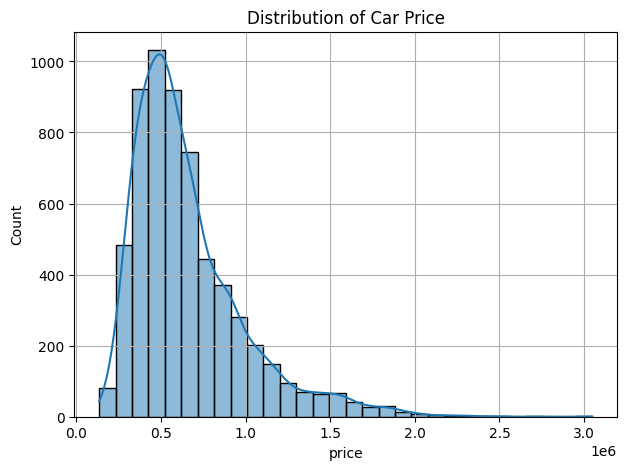

In [17]:
#price plot
plt.figure(figsize=(7,5))
sns.histplot(df["price"], kde=True, bins=30)
plt.title("Distribution of Car Price")
plt.grid()
plt.show()


In [18]:
print(df['price'].skew())
print(df['price'].kurtosis())

1.5943020712780607
3.370888768537104


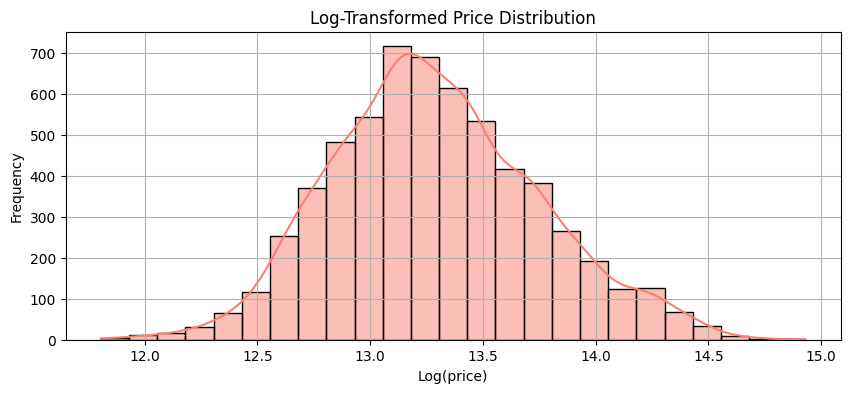

In [19]:
#Apply log transform if price has large range
#log1p = log(1 + x) to handle zero prices
df['log_price'] = np.log1p(df['price'])
plt.figure(figsize=(10, 4))
sns.histplot(df['log_price'], kde=True, bins=25, color='salmon')
plt.title('Log-Transformed Price Distribution')
plt.xlabel('Log(price)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

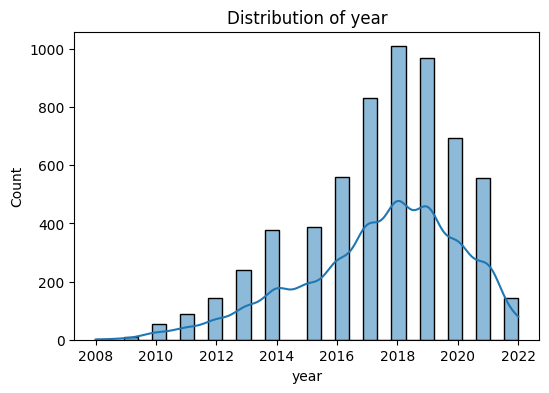

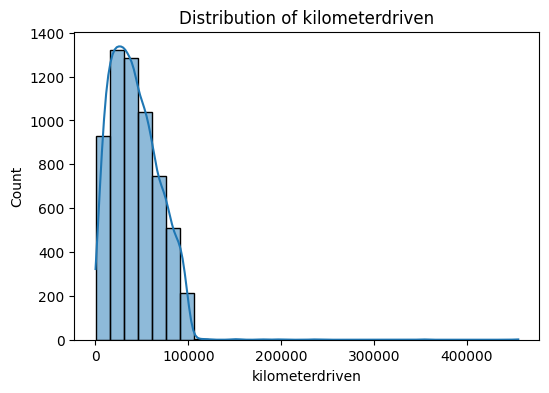

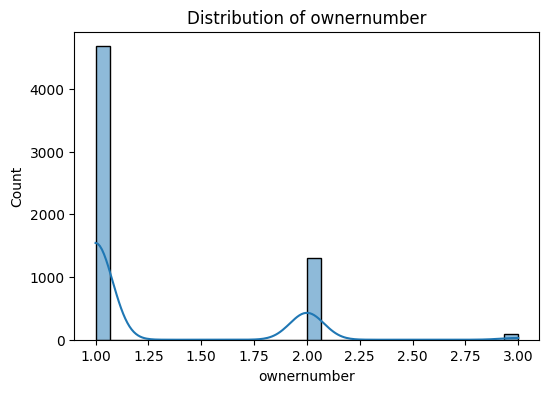

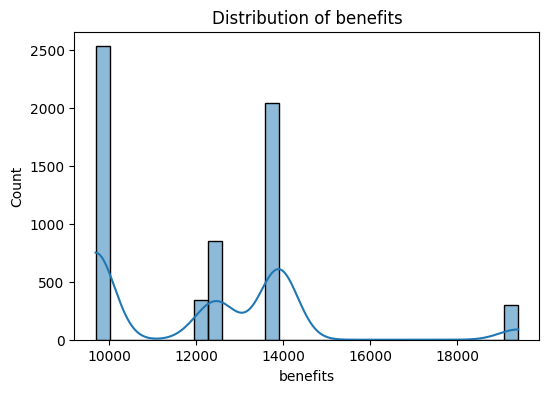

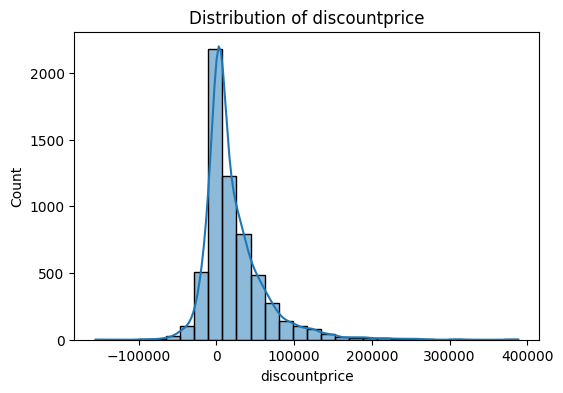

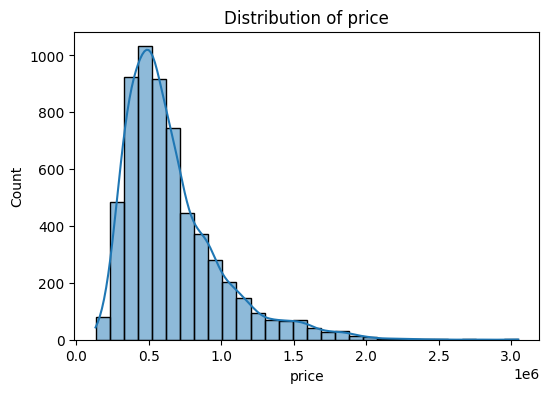

In [20]:
#numerical feature distribution
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()



In [21]:
#categorical value counts
for col in cat_cols:
    print(f"Value Counts of {col}")
    print(df[col].value_counts())
    print("\n")

Value Counts of name
name
Hyundai Grand i10     370
Maruti Swift          309
Maruti Wagon R 1.0    291
Hyundai Elite i20     289
Maruti Baleno         214
                     ... 
BMW 5 Series            1
Ford Figo               1
BMW X3                  1
Audi A6                 1
Nissan Sunny            1
Name: count, Length: 118, dtype: int64


Value Counts of make
make
Maruti           2484
Hyundai          1639
Honda             534
Renault           265
Tata              253
Ford              198
Mahindra          140
Volkswagen        130
Toyota            103
Kia                88
Skoda              60
Datsun             48
Mg                 45
Jeep               42
Nissan             22
Audi                3
Mercedes Benz       3
Bmw                 3
Jaguar              1
Name: count, dtype: int64


Value Counts of model
model
Grand I10      370
Swift          309
Wagon R 1.0    291
Elite I20      289
Baleno         214
              ... 
5 Series         1
Figo          

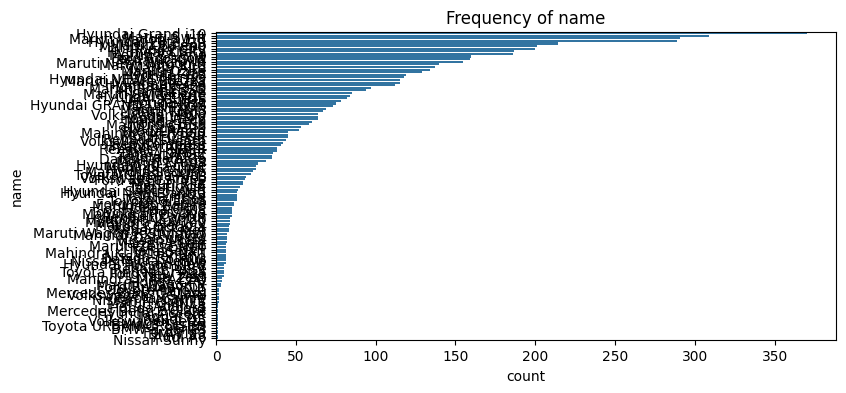

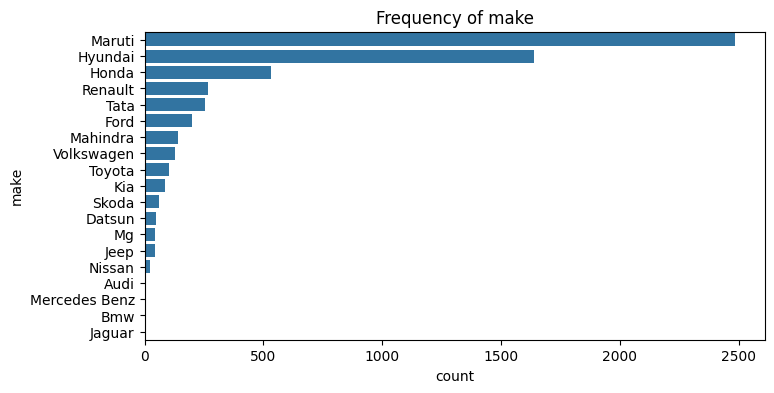

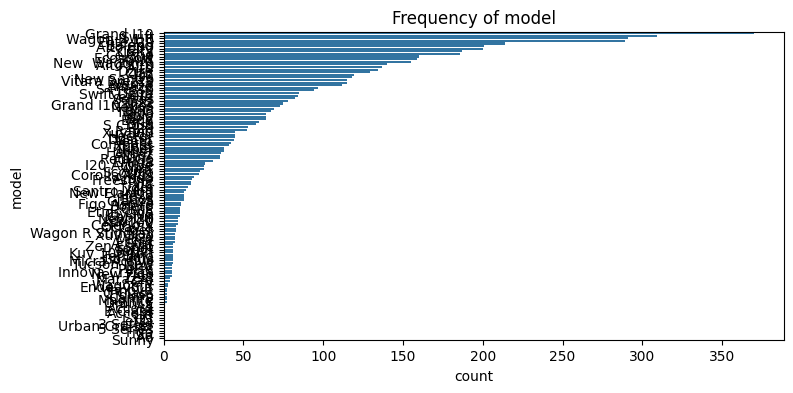

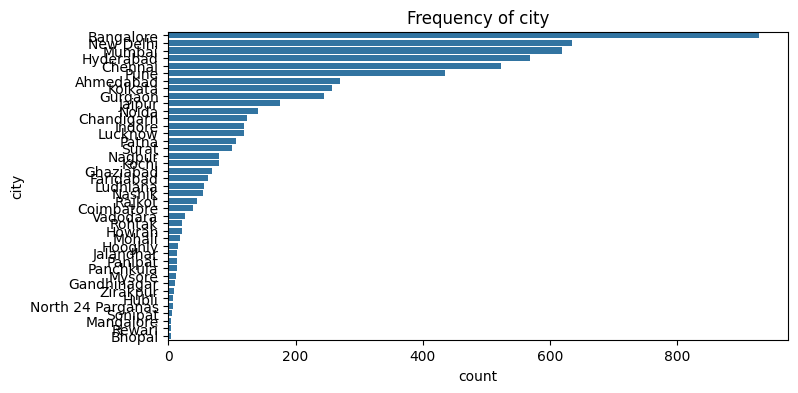

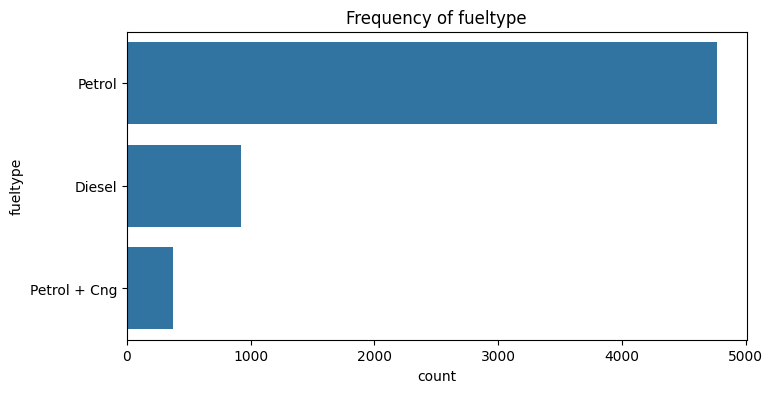

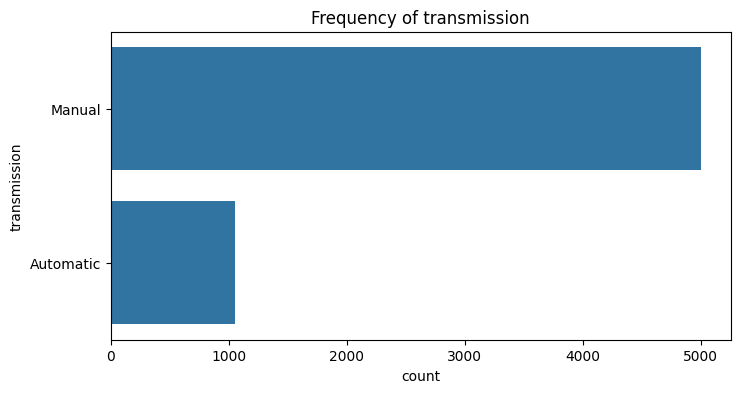

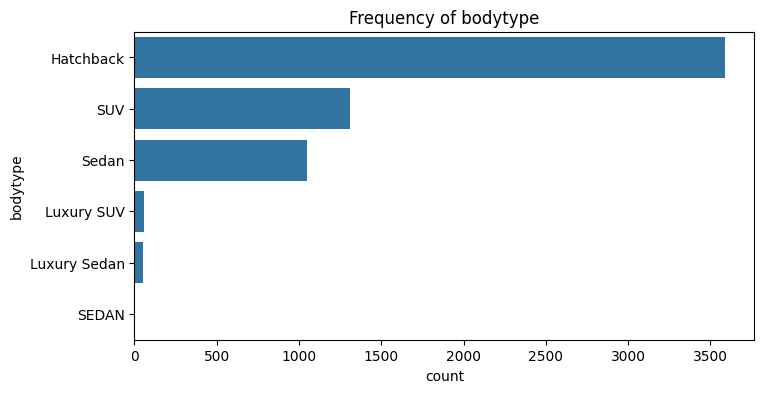

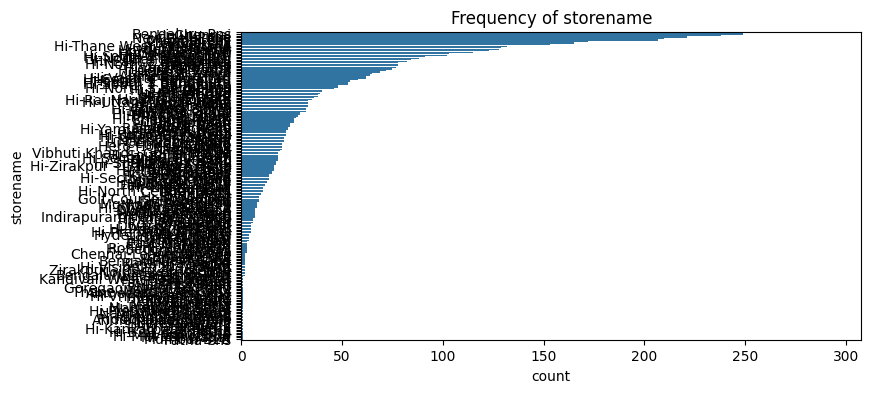

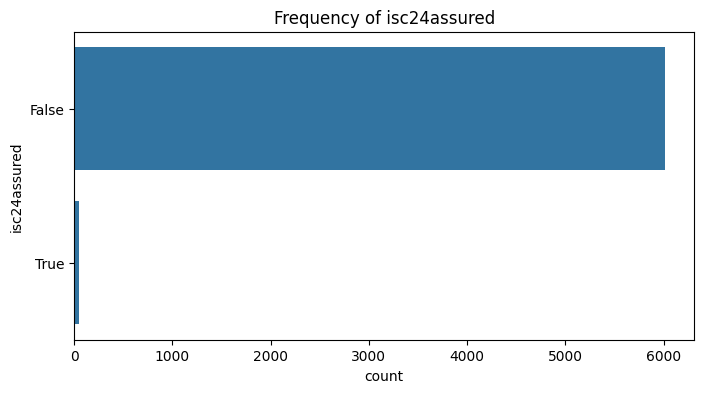

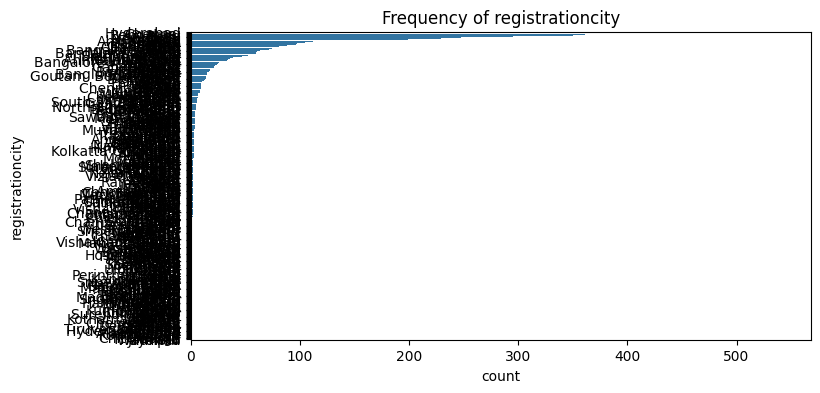

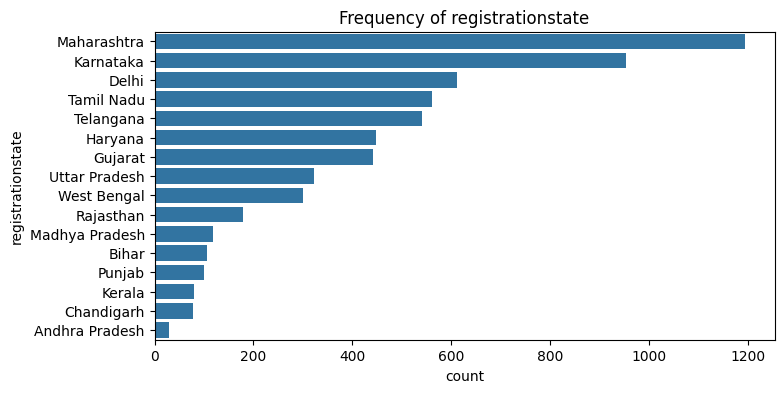

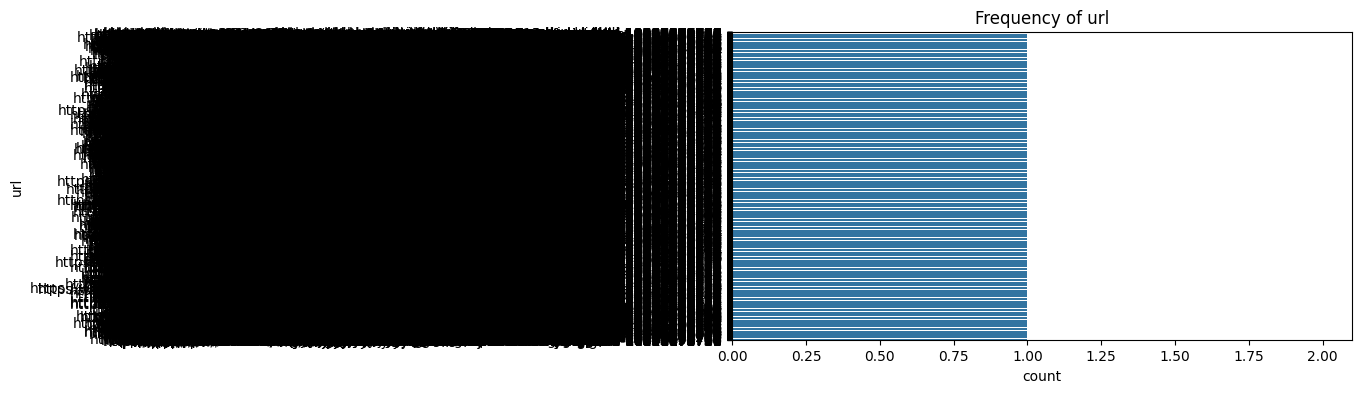

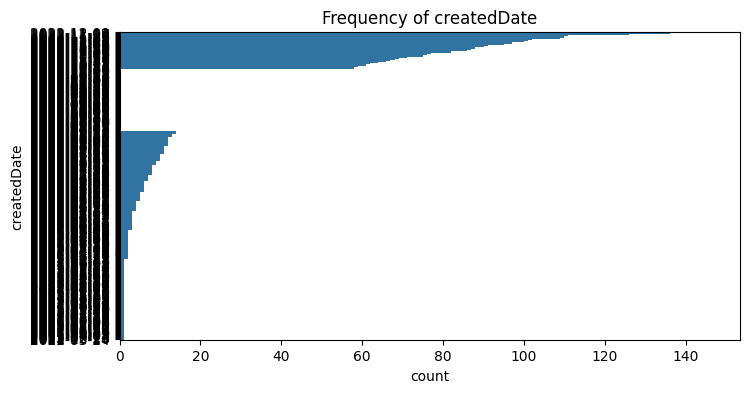

In [22]:
#Categorical features distribution
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f"Frequency of {col}")
    plt.show()

In [23]:
#outliers detection and seletion
def treat_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower, lower,
                       np.where(df[col] > upper, upper, df[col]))
    return df

for col in num_cols:
    df = treat_outliers_iqr(df, col)

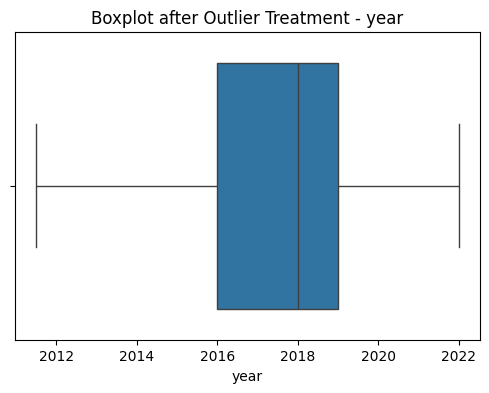

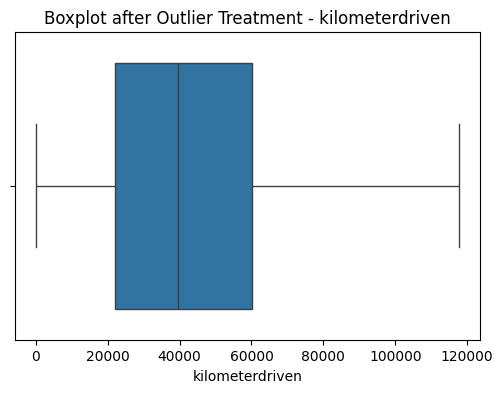

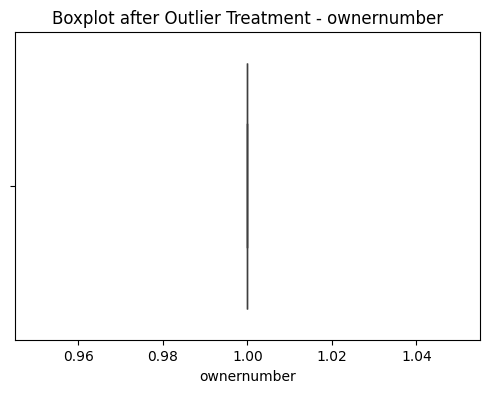

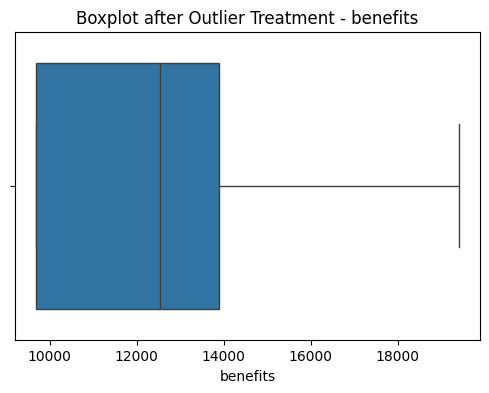

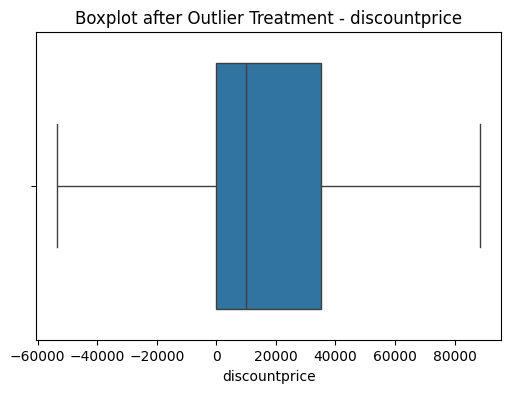

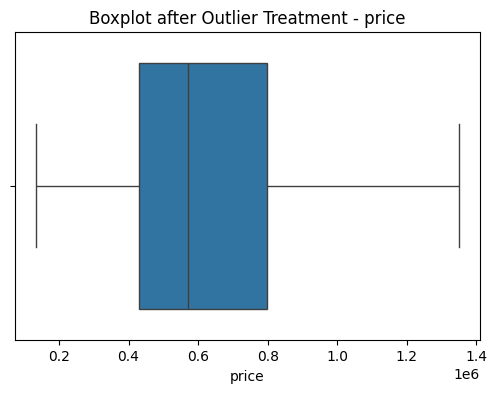

In [24]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot after Outlier Treatment - {col}")
    plt.show()

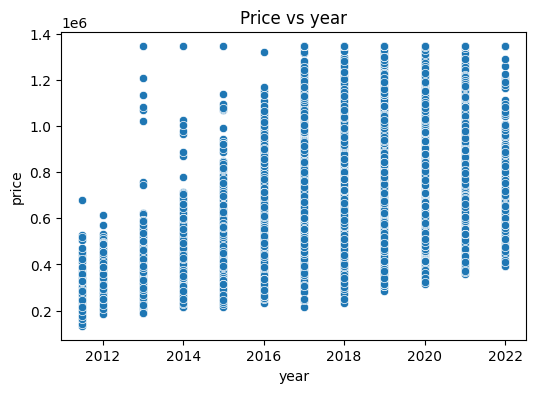

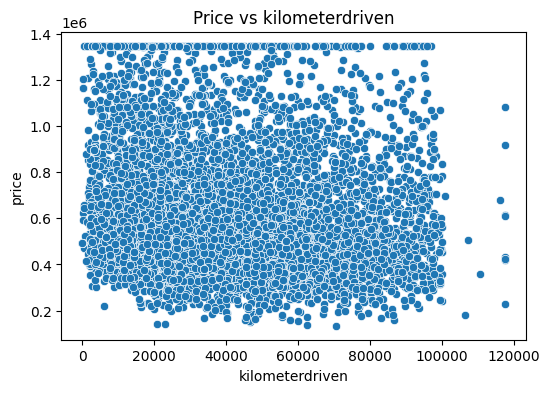

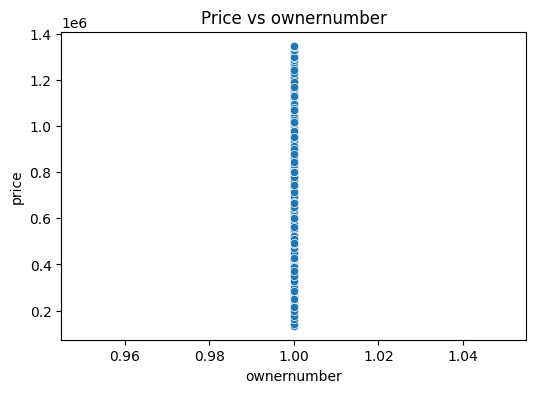

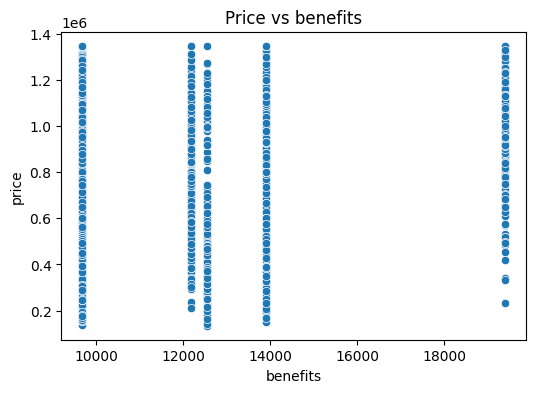

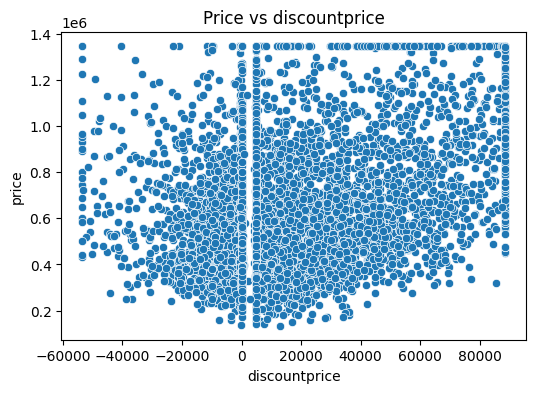

In [25]:
#Price vs Numerical Variables
for col in num_cols:
    if col != "price":
        plt.figure(figsize=(6,4))
        sns.scatterplot(x=df[col], y=df["price"])
        plt.title(f"Price vs {col}")
        plt.show()


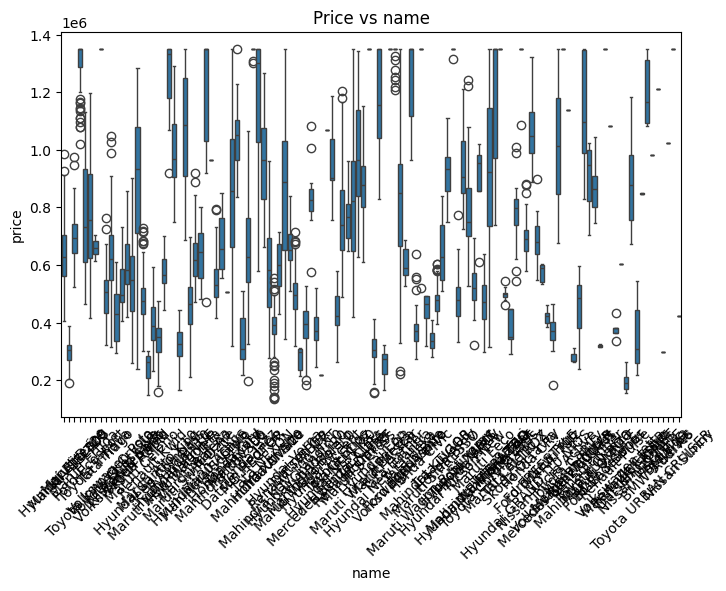

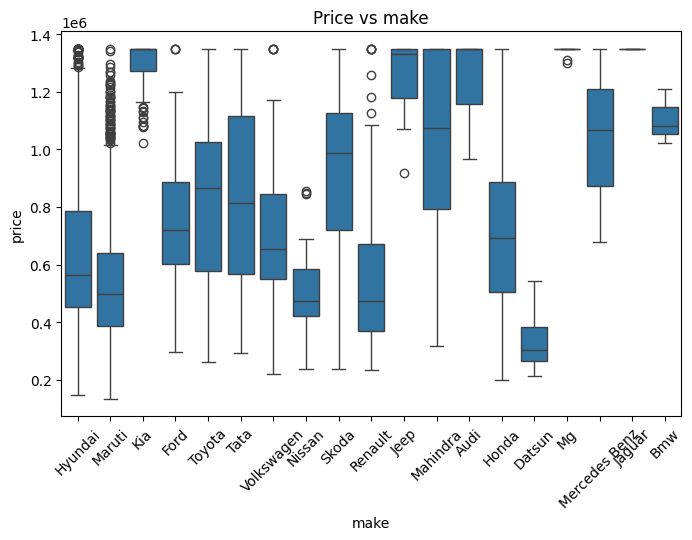

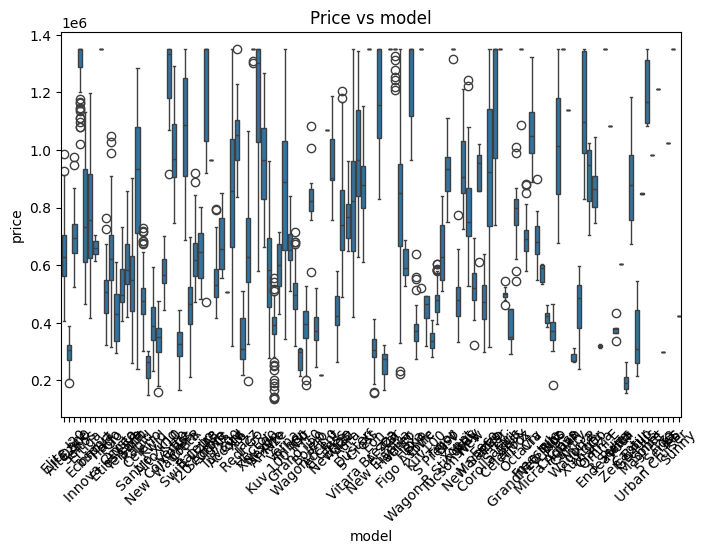

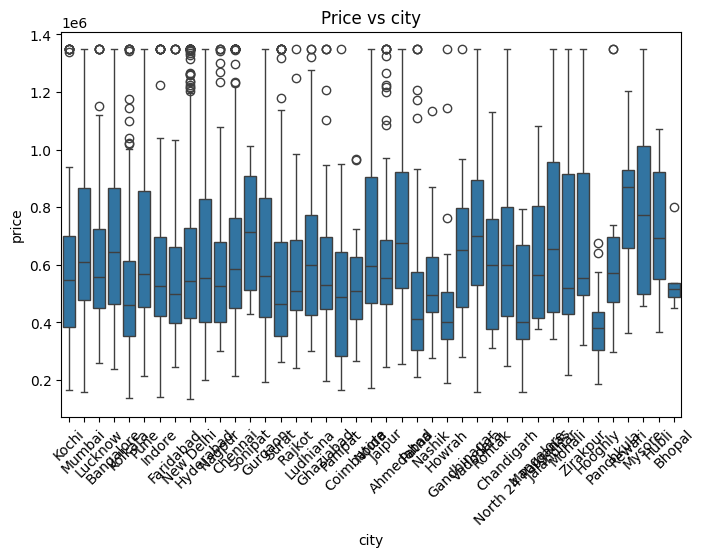

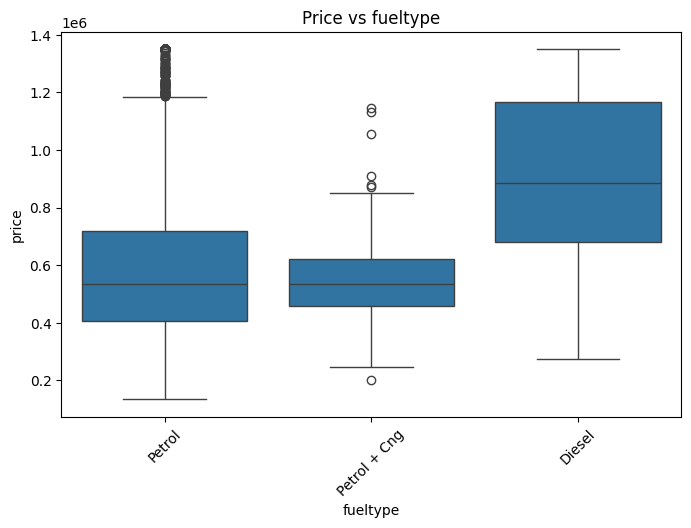

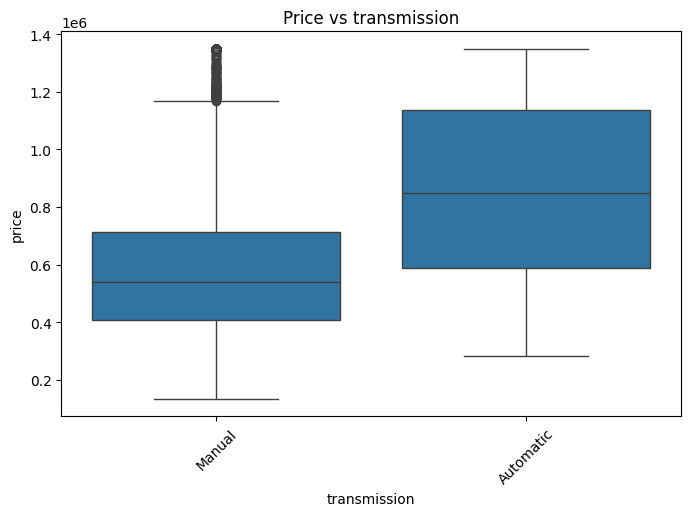

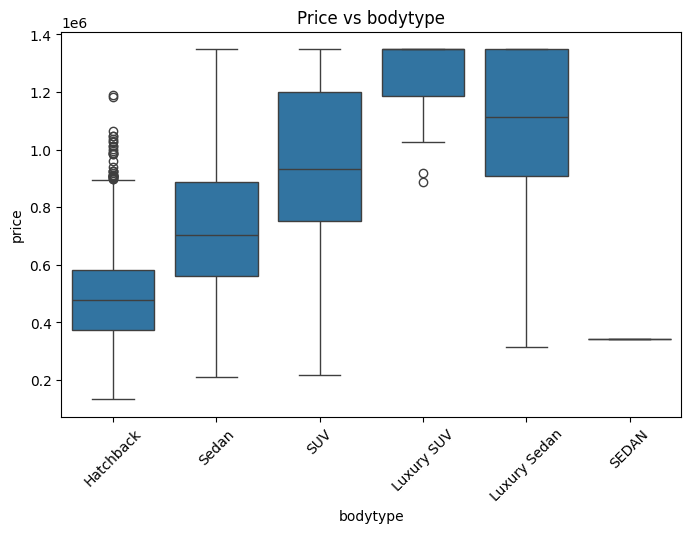

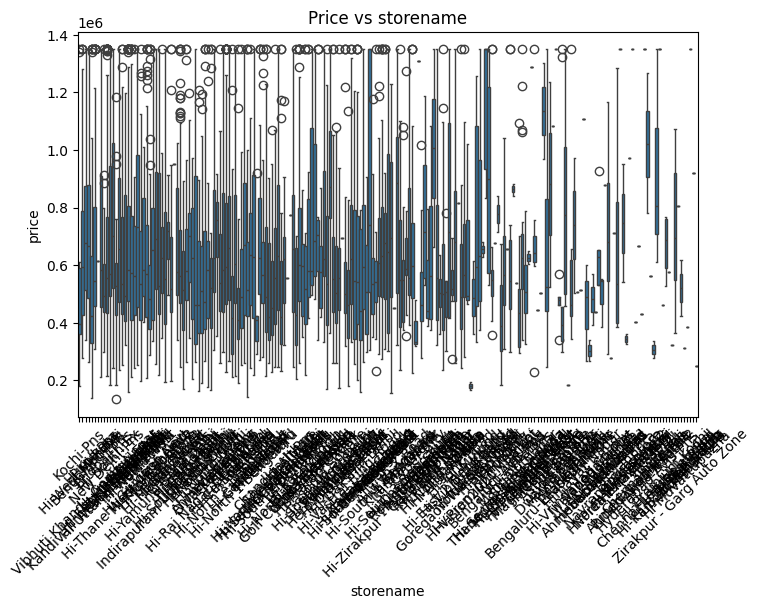

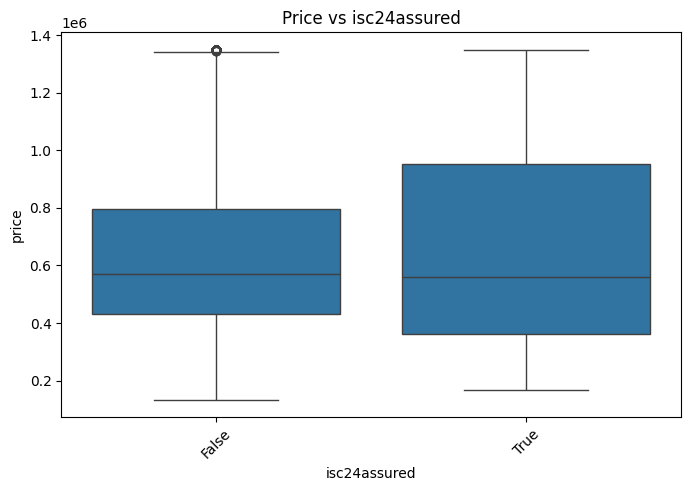

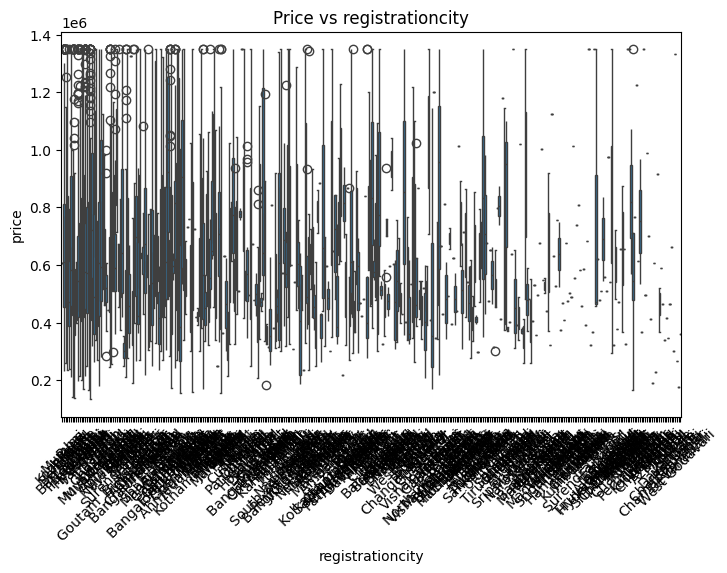

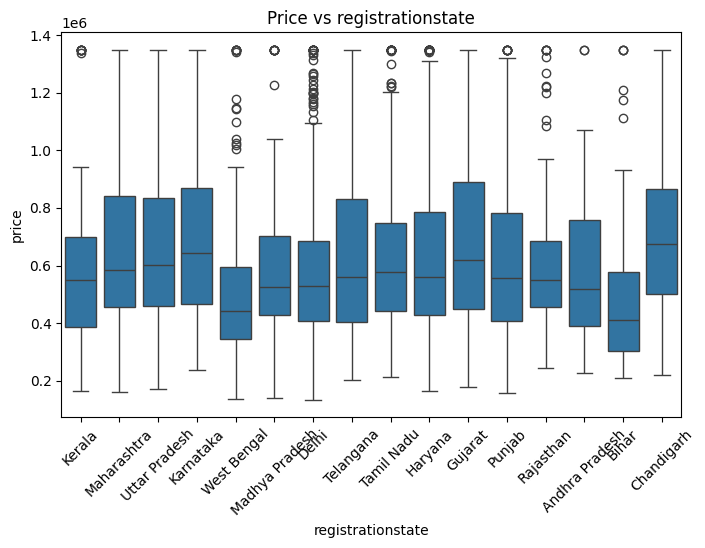

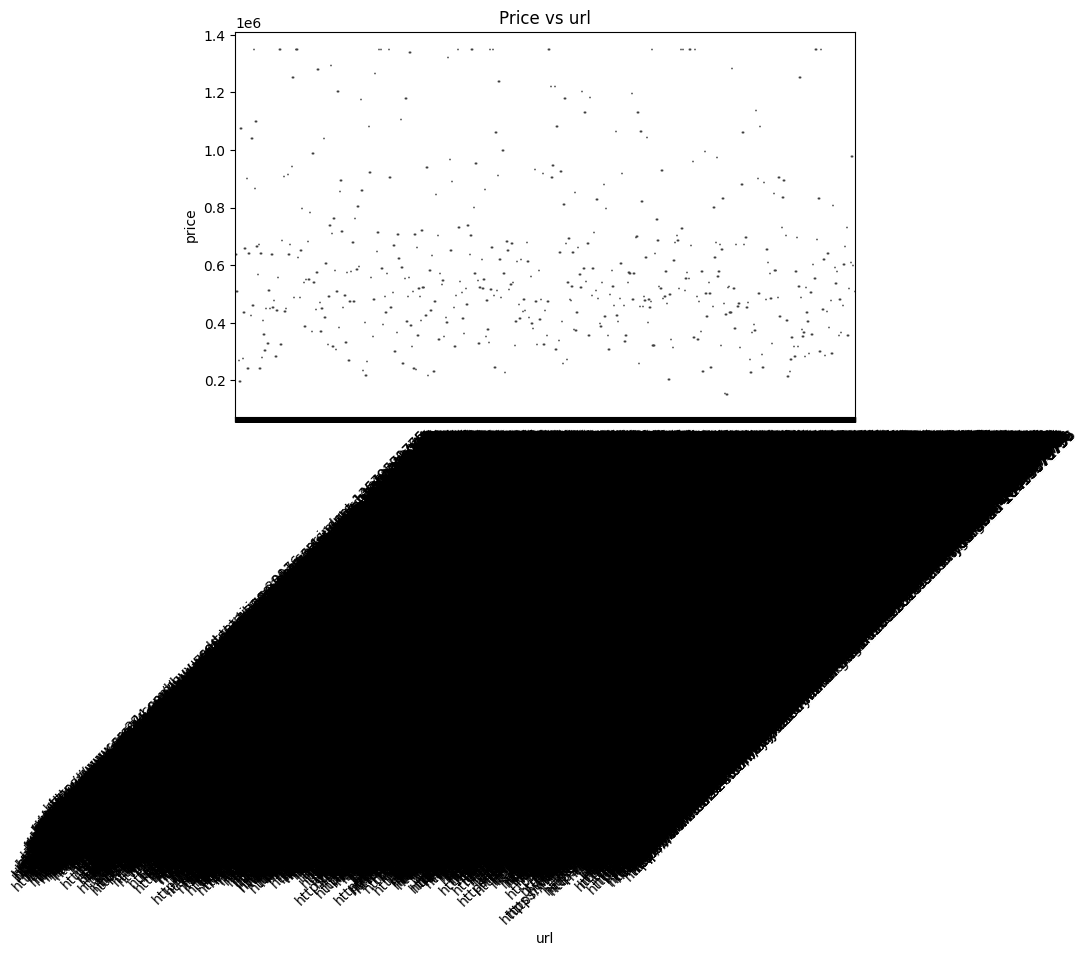

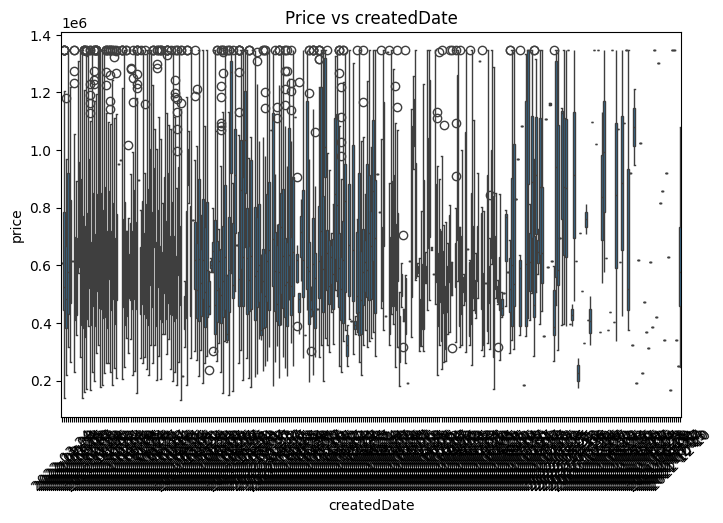

In [26]:
# Price vs Categorical Variables
for col in cat_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(x=df[col], y=df["price"])
    plt.title(f"Price vs {col}")
    plt.xticks(rotation=45)
    plt.show()


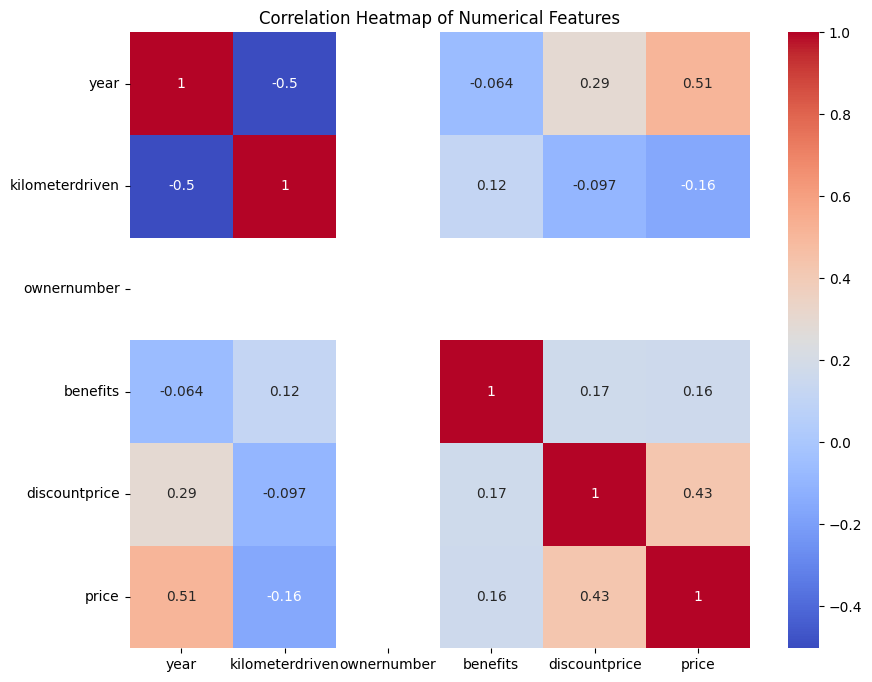

In [27]:
#correlation and heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

FEATURE INSIGHTS FROM EDA.

In [28]:
# Average price by fuel type
fuel_price = df.groupby("fueltype")["price"].mean().sort_values(ascending=False)
print("Average Price by Fuel Type:\n", fuel_price)

Average Price by Fuel Type:
 fueltype
Diesel          908711.942454
Petrol          600625.209897
Petrol + Cng    540265.716981
Name: price, dtype: float64


In [29]:
# Average price by transmission
trans_price = df.groupby("transmission")["price"].mean().sort_values(ascending=False)
print("\nAverage Price by Transmission:\n", trans_price)


Average Price by Transmission:
 transmission
Automatic    868436.433712
Manual       596338.667732
Name: price, dtype: float64


In [30]:
# Price trend by year (newer cars should cost more)
year_price = df.groupby("year")["price"].mean()
print("\nAverage Price by Year:\n", year_price.tail(10))  # last 10 years


Average Price by Year:
 year
2013.0    394082.380753
2014.0    428295.411141
2015.0    493950.701031
2016.0    548941.166071
2017.0    625693.853012
2018.0    663602.008920
2019.0    743621.830579
2020.0    814458.754690
2021.0    817583.559140
2022.0    869461.083333
Name: price, dtype: float64


In [31]:
# Effect of kms driven on price
kms_price_corr = df["kilometerdriven"].corr(df["price"])
print(f"\nCorrelation between Kms Driven and Price: {kms_price_corr:.2f}")


Correlation between Kms Driven and Price: -0.16


# **CONCLUSION**
From the EDA, we concluded that car age, kilometers driven, fuel type, transmission, and brand are the strongest predictors of resale price. These features will be the key inputs for building an accurate car price prediction model.

model building

In [32]:
#STEP 1: Import Libraries and Load Dataset
# This step loads all the necessary libraries for analysis, preprocessing, and modeling.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from joblib import dump

In [33]:
# STEP 2: Load the dataset
# Loading the Cars24 dataset into a DataFrame so we can work with it.
df = pd.read_csv('cars24_20221210.csv')
df

,name,make,model,city,year,fueltype,kilometerdriven,ownernumber,transmission,bodytype,storename,isc24assured,registrationcity,registrationstate,benefits,discountprice,price,url,createdDate
0,Hyundai Elite i20,Hyundai,Elite I20,Kochi,2017,Petrol,35939,2,Manual,Hatchback,Kochi-Pns,False,Kozhikode,Kerala,13898,47399,607000,https://www.cars24.com/buy-used-hyundai-elite-...,2022-03-24
1,Maruti Alto 800,Maruti,Alto 800,Mumbai,2016,Petrol + Cng,6180,1,Manual,Hatchback,Hi-West Mumbai,False,Mumbai,Maharashtra,12542,2099,326000,https://www.cars24.com/buy-used-maruti-alto-80...,2022-11-09
2,Maruti Dzire,Maruti,Dzire,Lucknow,2019,Petrol + Cng,46808,1,Manual,Sedan,Vibhuti Khand - Gomti Nagar,False,Lucknow,Uttar Pradesh,13898,26000,640000,https://www.cars24.com/buy-used-maruti-dzire-2...,2022-09-30
3,KIA SELTOS,Kia,Seltos,Bangalore,2020,Diesel,26045,1,Manual,SUV,Bengaluru-Pns,False,Bengaluru,Karnataka,9688,143700,1354000,https://www.cars24.com/buy-used-kia-seltos-202...,2022-07-04
4,Maruti Ertiga,Maruti,Ertiga,Kolkata,2017,Petrol,53056,1,Manual,SUV,Hi-Kolkata,False,Barrackpore,West Bengal,13898,22800,676000,https://www.cars24.com/buy-used-maruti-ertiga-...,2022-10-28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6432,Mahindra XUV500,Mahindra,Xuv500,Hyderabad,2013,Diesel,74570,2,Manual,SUV,Hi-West Hyd,False,Hyderabad,Telangana,9688,0,744000,https://www.cars24.com/buy-used-mahindra-xuv50...,2022-12-09
6433,Renault Kwid,Renault,Kwid,Chandigarh,2017,Petrol,39981,2,Manual,Hatchback,Chandigarh-Pns,False,Faridabad,Haryana,12542,0,248000,https://www.cars24.com/buy-used-renault-kwid-2...,2022-12-10
6434,Hyundai i10,Hyundai,I10,Hyderabad,2014,Petrol,61249,1,Manual,Hatchback,Hi-West 2 Hyd,False,Hyderabad,Telangana,13898,0,351000,https://www.cars24.com/buy-used-hyundai-i10-20...,2022-12-10
6435,Maruti Swift Dzire,Maruti,Swift Dzire,Hyderabad,2014,Petrol,48081,1,Manual,Sedan,Hi-West 2 Hyd,False,Hyderabad,Telangana,13898,0,494000,https://www.cars24.com/buy-used-maruti-swift-d...,2022-12-10


In [34]:
df.head()

,name,make,model,city,year,fueltype,kilometerdriven,ownernumber,transmission,bodytype,storename,isc24assured,registrationcity,registrationstate,benefits,discountprice,price,url,createdDate
0,Hyundai Elite i20,Hyundai,Elite I20,Kochi,2017,Petrol,35939,2,Manual,Hatchback,Kochi-Pns,False,Kozhikode,Kerala,13898,47399,607000,https://www.cars24.com/buy-used-hyundai-elite-...,2022-03-24
1,Maruti Alto 800,Maruti,Alto 800,Mumbai,2016,Petrol + Cng,6180,1,Manual,Hatchback,Hi-West Mumbai,False,Mumbai,Maharashtra,12542,2099,326000,https://www.cars24.com/buy-used-maruti-alto-80...,2022-11-09
2,Maruti Dzire,Maruti,Dzire,Lucknow,2019,Petrol + Cng,46808,1,Manual,Sedan,Vibhuti Khand - Gomti Nagar,False,Lucknow,Uttar Pradesh,13898,26000,640000,https://www.cars24.com/buy-used-maruti-dzire-2...,2022-09-30
3,KIA SELTOS,Kia,Seltos,Bangalore,2020,Diesel,26045,1,Manual,SUV,Bengaluru-Pns,False,Bengaluru,Karnataka,9688,143700,1354000,https://www.cars24.com/buy-used-kia-seltos-202...,2022-07-04
4,Maruti Ertiga,Maruti,Ertiga,Kolkata,2017,Petrol,53056,1,Manual,SUV,Hi-Kolkata,False,Barrackpore,West Bengal,13898,22800,676000,https://www.cars24.com/buy-used-maruti-ertiga-...,2022-10-28


In [35]:

# STEP 3: Feature Engineering

current_year = 2025

df['car_age'] = current_year - df['year']
df['car_age'] = df['car_age'].clip(lower=1)

df['km_per_year'] = df['kilometerdriven'] / df['car_age']

df['is_old_car'] = (df['car_age'] > 10).astype(int)

df['is_luxury_brand'] = df['make'].str.lower().isin(
    ['audi', 'bmw', 'mercedes', 'jaguar']
).astype(int)
#Feature Selection
features = [
    "make",
    "fueltype",
    "transmission",
    "bodytype",
    "year",
    "kilometerdriven",
    "ownernumber",
    "isc24assured",
    "registrationstate",
    "city"
]

X = df[features]
y = np.log1p(df["price"])

X = df[features]
y = np.log1p(df["price"])

X
y

0       13.316286
1       12.694656
2       13.369225
3       14.118574
4       13.423950
          ...    
6432    13.519798
6433    12.421188
6434    12.768544
6435    13.110293
6436    12.823960
Name: price, Length: 6437, dtype: float64

In [36]:
#STEP 5: Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [37]:
#displaying the features i created
df[['year', 'car_age', 'kilometerdriven', 'price', 'make', 'is_luxury_brand', 'is_old_car']].head(30)

,year,car_age,kilometerdriven,price,make,is_luxury_brand,is_old_car
0,2017,8,35939,607000,Hyundai,0,0
1,2016,9,6180,326000,Maruti,0,0
2,2019,6,46808,640000,Maruti,0,0
3,2020,5,26045,1354000,Kia,0,0
4,2017,8,53056,676000,Maruti,0,0
5,2014,11,85905,468000,Ford,0,1
6,2012,13,353288,615000,Toyota,0,1
7,2017,8,91964,1614000,Toyota,0,0
8,2017,8,47440,452000,Tata,0,0
9,2015,10,77595,368600,Volkswagen,0,0


In [38]:
### STEP 3.1: Revenue Estimation Column (Simulated)
assumed_margin_percent = 0.08  # 8% profit margin

df['estimated_margin'] = df['price'] * assumed_margin_percent
#This step helps simulate how much profit Cars24 earns on each car sale using a fixed 8% margin.
df['estimated_margin'].head(10)

0     48560.0
1     26080.0
2     51200.0
3    108320.0
4     54080.0
5     37440.0
6     49200.0
7    129120.0
8     36160.0
9     29488.0
Name: estimated_margin, dtype: float64

In [39]:
#STEP 6: Preprocessing Setup
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

categorical_cols = X.select_dtypes(include="object").columns
numeric_cols = X.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

rf = RandomForestRegressor(n_estimators=300, max_depth=15,
                           min_samples_split=5,
                           random_state=42)

final_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", rf)
])

final_pipeline.fit(X, y)




Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['year', 'kilometerdriven', 'ownernumber', 'isc24assured'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['make', 'fueltype', 'transmission', 'bodytype', 'registrationstate',
       'city'],
      dtype='object'))])),
                ('model',
                 RandomForestRegressor(max_depth=15, min_samples_split=5,
                                       n_estimators=300, random_state=42))])

In [40]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor(),
    "Random Forest (Base)": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )
}

results_base = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    y_test_actual = np.expm1(y_test)
    y_pred_actual = np.expm1(y_pred)

    results_base[name] = {
        "R2": r2_score(y_test_actual, y_pred_actual),
        "MAE": mean_absolute_error(y_test_actual, y_pred_actual),
        "RMSE": np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
    }

summary_base = pd.DataFrame(results_base).T
summary_base = summary_base.sort_values("R2", ascending=False)

print("===== Base Model Results =====")
print(summary_base)

===== Base Model Results =====
                            R2            MAE           RMSE
Random Forest (Base)  0.816403   98976.637086  143928.530684
SVR                   0.806218  101776.703385  147866.822366
Ridge                 0.776832  111181.385116  158682.719746
Linear Regression     0.776577  111257.372867  158773.408027
KNN                   0.710477  123486.765071  180740.353960
Lasso                -0.044907  241992.910944  343362.437991


In [42]:
# =========================================
# STEP 1: Import Libraries
# =========================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [43]:
# =========================================
# STEP 2: Create Pipeline
# =========================================
rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),   # your existing preprocessor
    ("model", RandomForestRegressor(random_state=42))
])


In [44]:
# =========================================
# STEP 3: Parameter Grid
# =========================================
param_dist = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [None, 15, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}


In [45]:
# =========================================
# STEP 4: Randomized Search
# =========================================
random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

best_rf_model = random_search.best_estimator_


In [46]:
# =========================================
# STEP 5: Evaluate Tuned Model
# =========================================
y_pred_rf_tuned = best_rf_model.predict(X_test)

y_test_actual = np.expm1(y_test)
y_pred_rf_tuned_actual = np.expm1(y_pred_rf_tuned)

r2_tuned = r2_score(y_test_actual, y_pred_rf_tuned_actual)
mae_tuned = mean_absolute_error(y_test_actual, y_pred_rf_tuned_actual)
rmse_tuned = np.sqrt(mean_squared_error(y_test_actual, y_pred_rf_tuned_actual))

print("\n===== Tuned Random Forest (FAST) =====")
print("R2:", r2_tuned)
print("MAE:", mae_tuned)
print("RMSE:", rmse_tuned)
print("Best Params:", random_search.best_params_)



===== Tuned Random Forest (FAST) =====
R2: 0.8178925705761513
MAE: 99207.19433455677
RMSE: 143343.41251636893
Best Params: {'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_depth': 15}


In [47]:
# =========================================
# STEP 6: Add to r2_scores Dictionary
# =========================================
r2_scores = {name: score_dict['R2'] for name, score_dict in results_base.items()} # Initialize and populate with base model R2 scores
r2_scores["Tuned Random Forest"] = r2_tuned


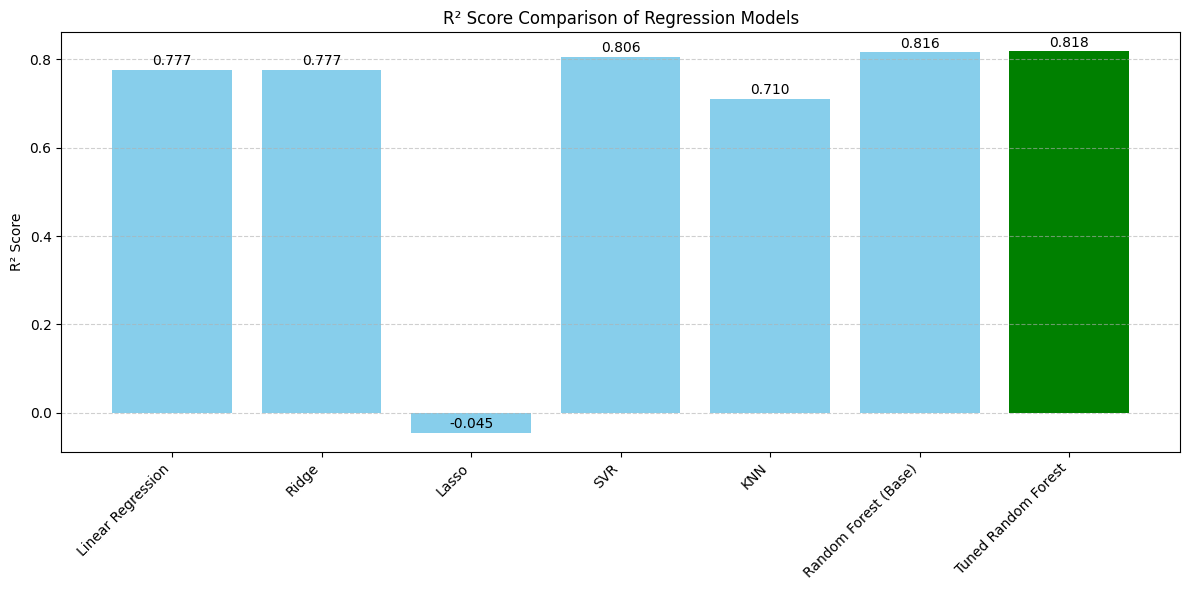

In [48]:
# =========================================
# STEP 7: Plot R² Comparison
# =========================================
plt.figure(figsize=(12, 6))

colors = ["green" if v == max(r2_scores.values()) else "skyblue"
          for v in r2_scores.values()]

bars = plt.bar(r2_scores.keys(), r2_scores.values(), color=colors)

plt.title("R² Score Comparison of Regression Models")
plt.ylabel("R² Score")
plt.xticks(rotation=45, ha='right')

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.01,
        f"{yval:.3f}",
        ha='center'
    )

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()




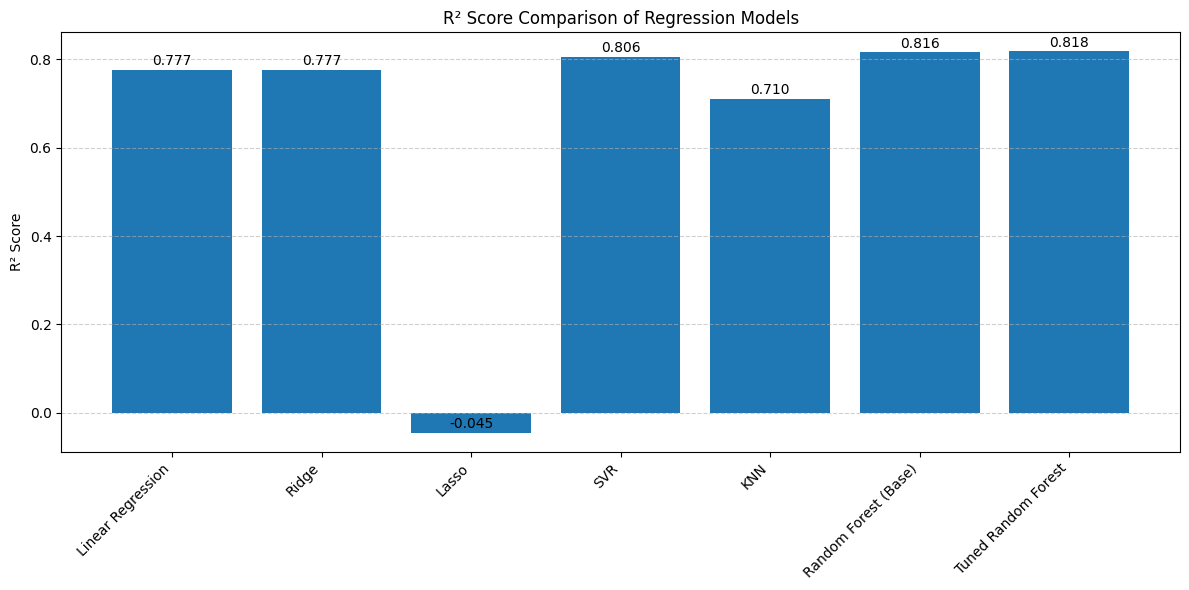

In [49]:
import matplotlib.pyplot as plt

# STEP 1: Create Figure
plt.figure(figsize=(12, 6))

# STEP 2: Create Bar Plot
bars = plt.bar(r2_scores.keys(), r2_scores.values())

# STEP 3: Add Title & Labels
plt.title("R² Score Comparison of Regression Models")
plt.ylabel("R² Score")
plt.xticks(rotation=45, ha='right')

# STEP 4: Add Value Labels Above Bars
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.01,
        f"{yval:.3f}",
        ha='center'
    )

# STEP 5: Add Grid
plt.grid(axis='y', linestyle='--', alpha=0.6)

# STEP 6: Adjust Layout
plt.tight_layout()

# STEP 7: Show Plot
plt.show()

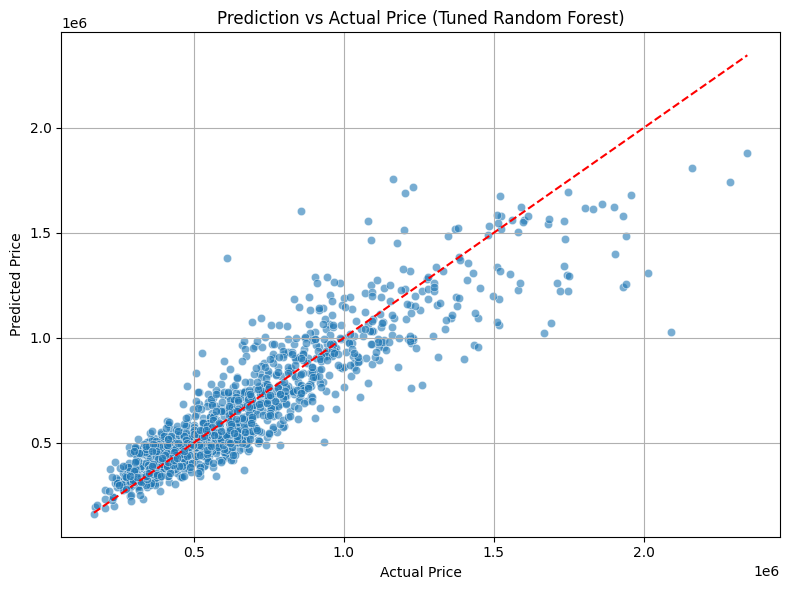

In [50]:
#9.2 Prediction vs Actual Plot (for Best Model - Random Forest)
# =========================================
# STEP 1: Predict Using Tuned Pipeline
# =========================================
y_pred_rf = best_rf_model.predict(X_test)

# Convert back from log scale
y_pred_rf_actual = np.expm1(y_pred_rf)
y_true_rf_actual = np.expm1(y_test)


# =========================================
# STEP 2: Scatter Plot
# =========================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_true_rf_actual,
    y=y_pred_rf_actual,
    alpha=0.6
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Prediction vs Actual Price (Tuned Random Forest)")

# Perfect prediction reference line
plt.plot(
    [y_true_rf_actual.min(), y_true_rf_actual.max()],
    [y_true_rf_actual.min(), y_true_rf_actual.max()],
    'r--'
)

plt.grid(True)
plt.tight_layout()
plt.show()

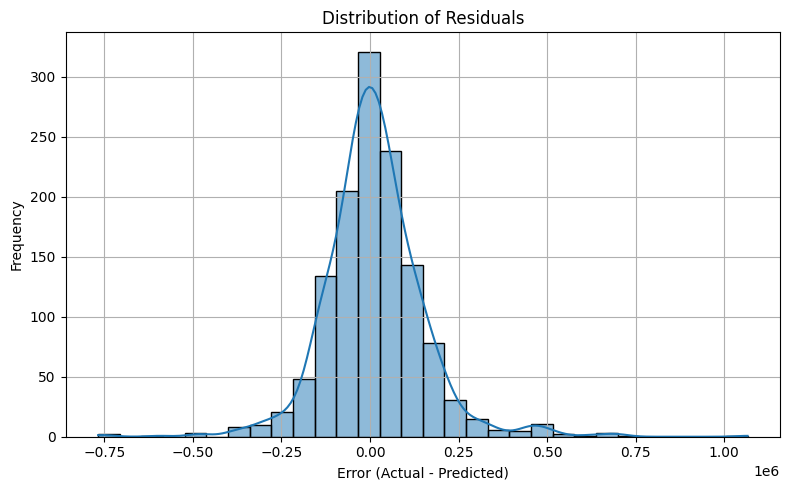

In [51]:
# =========================================
# STEP 1: Get Predictions (Actual Scale)
# =========================================
y_pred_rf = best_rf_model.predict(X_test)

y_pred_actual = np.expm1(y_pred_rf)
y_true_actual = np.expm1(y_test)


# =========================================
# STEP 2: Calculate Residuals
# =========================================
residuals = y_true_actual - y_pred_actual


# =========================================
# STEP 3: Plot Error Distribution
# =========================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.histplot(residuals, bins=30, kde=True)

plt.title("Distribution of Residuals")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")

plt.grid(True)
plt.tight_layout()
plt.show()


In [52]:
# =====================================
# Create Sample Input
# =====================================
sample = X.iloc[3:4].copy()

sample["car_age"] = 4
sample["kilometerdriven"] = 30000
# update other columns if needed



log_pred = best_rf_model.predict(sample)[0]

predicted_price = np.expm1(log_pred)

print(f"Predicted price: ₹{predicted_price:.2f}")

Predicted price: ₹1337415.62


In [53]:
# =====================================
# STEP 11: Revenue & Profit Summary by Brand
# =====================================

summary_stats = (
    df[['make', 'price', 'estimated_margin']]
    .groupby('make')
    .agg(
        total_cars=('price', 'count'),
        total_revenue=('price', 'sum'),
        total_margin=('estimated_margin', 'sum')
    )
    .sort_values(by='total_margin', ascending=False)
)

print("\nEstimated Revenue and Profit by Brand:")
print(summary_stats.head(10))


Estimated Revenue and Profit by Brand:
            total_cars  total_revenue  total_margin
make                                               
Maruti            2594     1399057013  1.119246e+08
Hyundai           1691     1098091587  8.784733e+07
Honda              534      387700421  3.101603e+07
Tata               290      271649436  2.173195e+07
Mahindra           181      209917985  1.679344e+07
Kia                124      177717297  1.421738e+07
Renault            291      169558079  1.356465e+07
Ford               200      154635783  1.237086e+07
Toyota             124      109938496  8.795080e+06
Volkswagen         141      107142890  8.571431e+06


In [54]:
# =========================================
# STEP 8: FINAL CLEAN DEPLOYMENT MODEL
# =========================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
import joblib

# Define final features
features = [
    "make",
    "fueltype",
    "transmission",
    "bodytype",
    "year",
    "kilometerdriven",
    "ownernumber",
    "isc24assured",
    "registrationstate",
    "city"
]

X = df[features]
y = np.log1p(df["price"])

categorical_cols = X.select_dtypes(include="object").columns
numeric_cols = X.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

final_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        min_samples_split=5,
        random_state=42
    ))
])

final_pipeline.fit(X, y)

joblib.dump(final_pipeline, "final_random_forest_model.pkl")

print("Final deployment model saved successfully!")

Final deployment model saved successfully!


In [49]:
import sklearn
print(sklearn.__version__)


1.6.1


In [55]:
import joblib

model = joblib.load('final_random_forest_model.pkl')
print("Model loaded successfully")

Model loaded successfully


## conclusion

From the exploratory data analysis (EDA), we identified several important factors influencing car resale prices, including car age, kilometers driven, fuel type, transmission type, and brand.

Based on these insights, we performed feature engineering by creating meaningful derived features (such as car age), which helped improve model learning and predictive performance.

We then trained and evaluated multiple regression models, including:

Linear Regression

Ridge Regression

Lasso Regression

Support Vector Regression (SVR)

K-Nearest Neighbors (KNN)

Random Forest

Each model was evaluated using performance metrics such as R² score, MAE, and RMSE.

After systematic comparison and hyperparameter tuning, Random Forest achieved the best balance between accuracy, stability, and generalization performance. Therefore, it was selected as the final model.

The tuned Random Forest model is now trained on the full dataset and ready for evaluation, deployment, or integration into a prediction application.